# Inferencia Estadística y A/B Testing

**Ciencia de Datos, Sección A** · Sesión 6 · 6 de agosto de 2026

Notebook companion de la presentación. Corran cada celda con `Shift+Enter`.

Dependencias: `pip install numpy matplotlib`

## 1. El TCL, visto con simulación

Da igual de qué distribución vengan los datos: el **promedio** de muestras grandes se ve Normal.

El error estándar de la media es $\mathrm{SE}(\bar{x}) = \sigma/\sqrt{n}$: para reducirlo a la mitad hay que **cuadruplicar** la muestra.

In [1]:
import numpy as np

rng = np.random.default_rng(0)

# Población nada normal: exponencial, muy sesgada
pob = rng.exponential(scale=3, size=1_000_000)
print(pob.mean(), pob.std())

medias = np.empty(5000)
for i in range(5000):
    muestra = rng.choice(pob, size=100)
    medias[i] = muestra.mean()

print(medias.mean(), medias.std())   # ~3 y ~0.3 = sigma / sqrt(100)

2.9991778123517943 3.0043240241690454
2.9949253939212204 0.30095223553933836


In [2]:
# Sin librerías de gráficos: un histograma en texto
conteo, bordes = np.histogram(medias, bins=15)
for c, b in zip(conteo, bordes):
    print(f"{b:5.2f} | " + "#" * (c // 20))

 1.99 | 
 2.14 | #
 2.29 | ####
 2.43 | #############
 2.58 | ############################
 2.73 | #########################################
 2.88 | #################################################
 3.03 | ###########################################
 3.17 | ##############################
 3.32 | ####################
 3.47 | ###########
 3.62 | ###
 3.76 | #
 3.91 | 
 4.06 | 


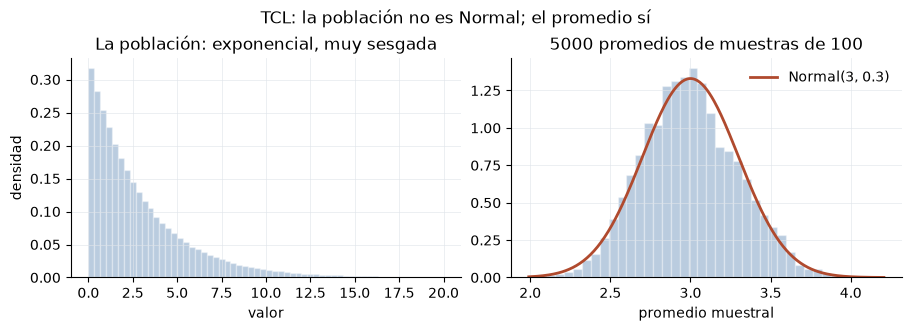

In [3]:
import matplotlib.pyplot as plt

AZUL, ROJO, GRIS, LINEA = "#3A6EA5", "#B04A2E", "#75808E", "#E0E4EA"

def eje_limpio(ax):
    ax.grid(color=LINEA, lw=0.6, alpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), layout="constrained")

axes[0].hist(pob, bins=60, range=(0, 20), density=True, color=AZUL,
             alpha=0.35, edgecolor="white")
axes[0].set_title("La población: exponencial, muy sesgada")
axes[0].set_xlabel("valor")
axes[0].set_ylabel("densidad")

axes[1].hist(medias, bins=40, density=True, color=AZUL,
             alpha=0.35, edgecolor="white")
xs = np.linspace(medias.min(), medias.max(), 300)
se = 3 / np.sqrt(100)
axes[1].plot(xs, np.exp(-(xs - 3)**2 / (2 * se**2)) / (se * np.sqrt(2 * np.pi)),
             color=ROJO, lw=2, label="Normal(3, 0.3)")
axes[1].set_title("5000 promedios de muestras de 100")
axes[1].set_xlabel("promedio muestral")
axes[1].legend(frameon=False)

for ax in axes:
    eje_limpio(ax)
fig.suptitle("TCL: la población no es Normal; el promedio sí")
plt.show()

## 2. Intervalos de confianza

Un intervalo del 95% se construye como $\bar{x} \pm 1.96 \times \mathrm{SE}$.

- **Sí significa**: si repitiéramos el estudio muchas veces, el 95% de los intervalos construidos así contendrían el parámetro verdadero.
- **No significa**: que haya 95% de probabilidad de que el parámetro esté en *este* intervalo. El parámetro es fijo; lo aleatorio es el intervalo.

In [4]:
def intervalo(muestra):
    se = muestra.std(ddof=1) / np.sqrt(len(muestra))
    m = muestra.mean()
    return m - 1.96*se, m + 1.96*se

# ¿Cuántos de 1000 intervalos atrapan la media verdadera (3.0)?
atrapan = 0
for i in range(1000):
    m = rng.exponential(scale=3, size=200)
    lo, hi = intervalo(m)
    atrapan += (lo <= 3.0 <= hi)

print(atrapan / 1000)   # cerca de 0.95

0.937


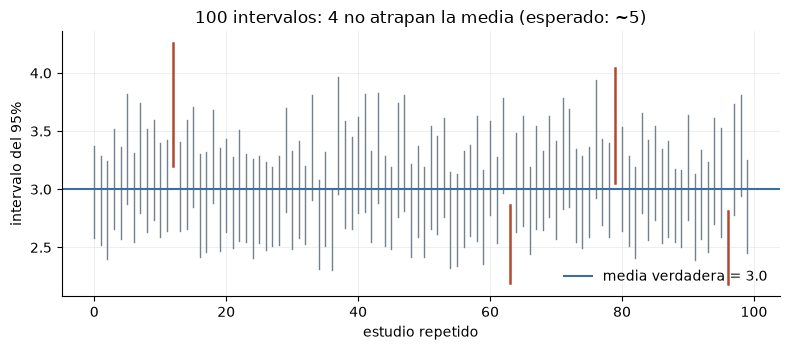

In [5]:
rng_ic = np.random.default_rng(21)

fig, ax = plt.subplots(figsize=(8, 3.6))
fallan = 0
for i in range(100):
    m = rng_ic.exponential(scale=3, size=200)
    lo, hi = intervalo(m)
    atrapa = lo <= 3.0 <= hi
    fallan += not atrapa
    ax.plot([i, i], [lo, hi], color=GRIS if atrapa else ROJO,
            lw=1 if atrapa else 1.8)
ax.axhline(3.0, color=AZUL, lw=1.5, label="media verdadera = 3.0")
ax.set_xlabel("estudio repetido")
ax.set_ylabel("intervalo del 95%")
ax.set_title(f"100 intervalos: {fallan} no atrapan la media (esperado: ~5)")
ax.legend(frameon=False, loc="lower right")
eje_limpio(ax)
plt.tight_layout()
plt.show()

# El parámetro (la línea azul) nunca se mueve. Los que cambian de
# estudio a estudio son los intervalos: eso es lo aleatorio.

## 3. El p-value

$$p = P(\text{datos así de extremos o más} \mid H_0 \text{ cierta})$$

**Lo que NO es:**

- No es $P(H_0 \mid \text{datos})$: eso requiere un prior (sesión del martes)
- No es la probabilidad de haberse equivocado
- No mide el tamaño del efecto: con $n$ gigante, una diferencia trivial da $p$ minúsculo
- No es replicabilidad: $p = 0.04$ no significa que el estudio se replique el 96% de las veces
- $p = 0.049$ y $p = 0.051$ no son mundos distintos

## 4. Test de permutación desde cero

El experimento del botón: control 4,000 visitantes al 10.0%, variante 4,000 al 11.5%.

Si el botón no importara, las etiquetas A y B serían intercambiables. Entonces las revolvemos miles de veces y vemos qué diferencias produce el puro azar.

In [6]:
rng = np.random.default_rng(7)

a = rng.binomial(1, 0.100, 4000)   # control
b = rng.binomial(1, 0.115, 4000)   # variante
obs = b.mean() - a.mean()

todos = np.concatenate([a, b])
dif = np.empty(10000)
for i in range(10000):
    rng.shuffle(todos)
    dif[i] = todos[4000:].mean() - todos[:4000].mean()

p_val = np.mean(np.abs(dif) >= abs(obs))
print(obs, p_val)

0.017 0.0149


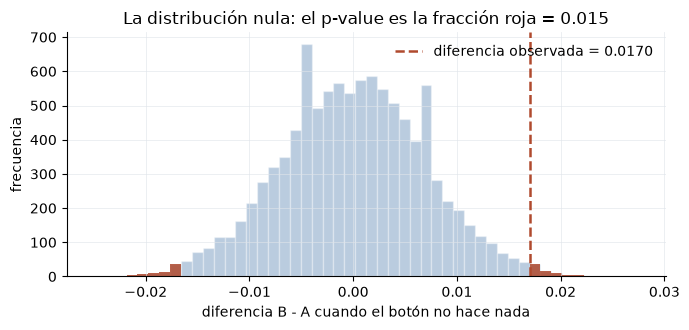

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.4))
conteo, bordes, _ = ax.hist(dif, bins=50, color=AZUL, alpha=0.35,
                            edgecolor="white")
ax.hist(dif[np.abs(dif) >= abs(obs)], bins=bordes, color=ROJO, alpha=0.85)
ax.axvline(obs, color=ROJO, ls="--", lw=1.8,
           label=f"diferencia observada = {obs:.4f}")
ax.set_xlabel("diferencia B - A cuando el botón no hace nada")
ax.set_ylabel("frecuencia")
ax.set_title(f"La distribución nula: el p-value es la fracción roja = {p_val:.3f}")
ax.legend(frameon=False)
eje_limpio(ax)
plt.tight_layout()
plt.show()

`dif` es la distribución nula: lo que produce el azar cuando el tratamiento no hace nada. El p-value es la fracción de esas diferencias que iguala o supera la nuestra. Sin `scipy`, sin tablas.

## 5. El peeking problem

Revisar el p-value cada día y parar apenas cruce 0.05 es la forma más rápida de inventarse resultados. Aquí $H_0$ es **cierta**: los dos grupos vienen de la misma distribución.

In [8]:
def z(a, b):
    s = np.sqrt(a.var()/len(a) + b.var()/len(b))
    return (b.mean() - a.mean()) / s

def corre(peek, rng):
    a = rng.normal(0, 1, 1000)
    b = rng.normal(0, 1, 1000)   # H0 es CIERTA
    cortes = range(100, 1001, 100) if peek else [1000]
    return any(abs(z(a[:n], b[:n])) > 1.96 for n in cortes)

In [9]:
rng = np.random.default_rng(11)

sin_peek = sum(corre(False, rng) for _ in range(1000)) / 1000
con_peek = sum(corre(True, rng) for _ in range(1000)) / 1000

print(sin_peek, con_peek)   # ~0.05 vs ~0.20

0.045 0.192


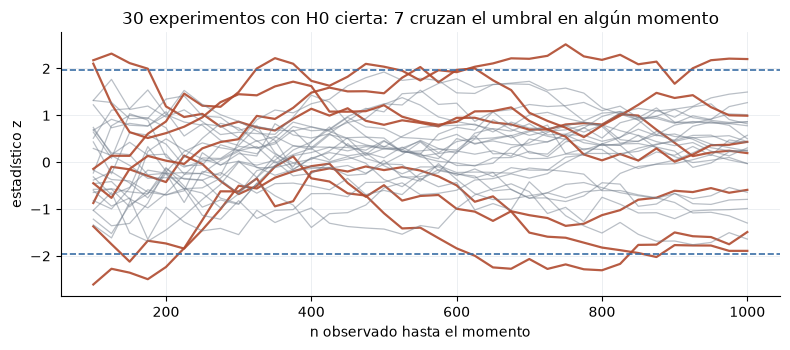

In [10]:
rng_pk = np.random.default_rng(13)

fig, ax = plt.subplots(figsize=(8, 3.6))
pasos = list(range(100, 1001, 25))
cruzan = 0
for _ in range(30):
    a = rng_pk.normal(0, 1, 1000)
    b = rng_pk.normal(0, 1, 1000)   # H0 es CIERTA
    zs = [z(a[:n], b[:n]) for n in pasos]
    cruza = np.any(np.abs(zs) > 1.96)
    cruzan += cruza
    ax.plot(pasos, zs, color=ROJO if cruza else GRIS,
            lw=1.6 if cruza else 0.9, alpha=0.9 if cruza else 0.5)
ax.axhline(1.96, color=AZUL, ls="--", lw=1.2)
ax.axhline(-1.96, color=AZUL, ls="--", lw=1.2)
ax.set_xlabel("n observado hasta el momento")
ax.set_ylabel("estadístico z")
ax.set_title(f"30 experimentos con H0 cierta: {cruzan} cruzan el umbral en algún momento")
eje_limpio(ax)
plt.tight_layout()
plt.show()

# Quien hace peeking se queda con el primer cruce y publica.
# Quien espera al final solo comete el error del 5%.

## 6. Comparaciones múltiples y Bonferroni

Con $\alpha = 0.05$, cada test bajo $H_0$ tiene 5% de dar falso positivo:

$$P(\text{al menos un falso positivo}) = 1 - 0.95^{20} = 0.64$$

Corrección de **Bonferroni**: usar $\alpha/m$ con $m$ tests.

In [11]:
for m in [1, 5, 20, 100]:
    sin_corregir = 1 - 0.95**m
    con_bonferroni = 1 - (1 - 0.05/m)**m
    print(m, round(sin_corregir, 3), round(con_bonferroni, 3))

1 0.05 0.05
5 0.226 0.049
20 0.642 0.049
100 0.994 0.049


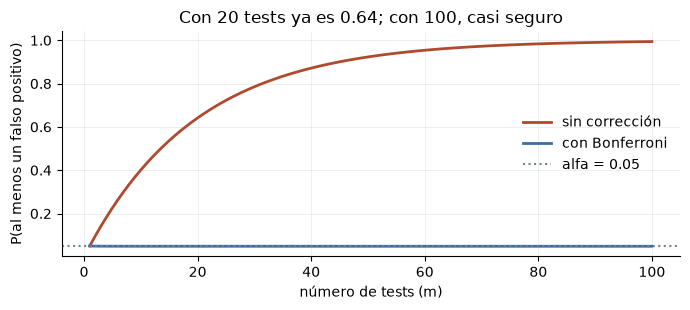

In [12]:
ms = np.arange(1, 101)

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(ms, 1 - 0.95**ms, color=ROJO, lw=2, label="sin corrección")
ax.plot(ms, 1 - (1 - 0.05/ms)**ms, color=AZUL, lw=2, label="con Bonferroni")
ax.axhline(0.05, color=GRIS, ls=":", lw=1.5, label="alfa = 0.05")
ax.set_xlabel("número de tests (m)")
ax.set_ylabel("P(al menos un falso positivo)")
ax.set_title("Con 20 tests ya es 0.64; con 100, casi seguro")
ax.legend(frameon=False)
eje_limpio(ax)
plt.tight_layout()
plt.show()

## 7. Ejercicios

Completen donde dice `# ¿Qué va aquí?`.

### Ejercicio 1: test de permutación desde cero

Escriban la función completa y úsenla con dos grupos simulados.

In [13]:
def test_permutacion(a, b, reps=10000, seed=1):
    rng = np.random.default_rng(seed)
    obs = b.mean() - a.mean()
    # ¿Qué va aquí?
    # 1) concatenar a y b
    # 2) repetir reps veces: revolver y partir en dos del tamaño original
    # 3) guardar la diferencia de medias
    # 4) devolver la fracción de diferencias tan extremas como obs
    pass

# Verificación (descomenten al terminar):
# r = np.random.default_rng(4)
# g1 = r.normal(50, 10, 300)
# g2 = r.normal(52, 10, 300)
# print(test_permutacion(g1, g2))

### Ejercicio 2: simular el peeking

Midan la tasa real de falsos positivos con y sin peeking, usando `corre` de la sección 5.

In [14]:
rng = np.random.default_rng(11)

resultados_sin = [corre(False, rng) for _ in range(1000)]
resultados_con = [corre(True, rng) for _ in range(1000)]

# a) tasa de falsos positivos de cada uno
tasa_sin = ...
tasa_con = ...

# b) ¿cuántas veces más alta es la segunda?
razon = ...

# Verificación: tasa_sin ~ 0.05, tasa_con ~ 0.20
# c) ¿Qué pasa si revisan cada 50 observaciones en vez de cada 100?

### Ejercicio 3: 100 tests bajo H0 pura

Ningún efecto existe. ¿Cuántos "descubrimientos" aparecen igual?

In [15]:
rng = np.random.default_rng(2)
significativos = 0

for i in range(100):
    a = rng.normal(0, 1, 500)
    b = rng.normal(0, 1, 500)   # exactamente la misma distribución
    # ¿Qué va aquí?  Usen z(a, b) y el umbral 1.96
    pass

# print(significativos)   # esperado: alrededor de 5

# Ahora repitan con el umbral de Bonferroni: alpha/100 en vez de alpha.
# Pista: el umbral z para alpha=0.0005 a dos colas es aproximadamente 3.48

## Lo esencial de hoy

- Todo estimador tiene incertidumbre: $\mathrm{SE} = \sigma/\sqrt{n}$
- El p-value es $P(\text{datos extremos} \mid H_0)$, nada más
- Fijen métrica, $n$ y duración **antes** de correr el test
- **Peeking** y **comparaciones múltiples** inflan los falsos positivos; Bonferroni es la corrección mínima
- Significancia estadística no es significancia práctica
- Si puedo simular $H_0$, no necesito memorizar fórmulas

**Próxima clase (jueves 13): Naive Bayes.** No hay clase el martes 11: Festival de la Libertad.